# Part 2: Algorithmic Bias Investigation

### 1. Objective

This section examines whether modern mortgage lending outcomes differ between areas with historical racial covenants and areas without them. Even if modern lending systems do not directly use race, they may still rely on variables such as neighborhood characteristics, income levels, and property values, which can act as proxy variables. The goal is to test whether these patterns appear in mortgage approvals and loan terms.

### 2. Methodology

To study algorithmic bias, I compared mortgage lending outcomes in covenant and non-covenant areas using the provided dataset. First, I created a binary grouping variable based on whether a census tract had any recorded covenants. Then I compared approval rates, interest rates, and loan amounts across these two groups. After that, I examined possible proxy variables such as property value, applicant income, minority population percentage, and tract-to-MSA income percentage. Finally, I used logistic regression and fairness metrics to test whether covenant-related neighborhood history is associated with modern mortgage approval outcomes.

### 3. Algorithmic Bias Analysis Code

### Import libraries

In [25]:
# Basic libraries for data work and charts
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For the logistic regression model
import statsmodels.api as sm

# Just to make the plots look a little cleaner
sns.set_theme(style="whitegrid")

### Load dataset

In [27]:
df = pd.read_csv("data/mortgage_covenant_data.csv",index_col = None, header = 0)

print(df.head())
print("\nShape of the dataset:", df.shape)
print("\nColumns:\n", df.columns.tolist())

   activity_year  census_tract        derived_race  action_taken  loan_amount  \
0           2023  2.703706e+10  Race Not Available             6     185000.0   
1           2023  2.714103e+10  Race Not Available             6     375000.0   
2           2023  2.702395e+10  Race Not Available             6     105000.0   
3           2023  2.717110e+10  Race Not Available             6     285000.0   
4           2023  2.715948e+10  Race Not Available             6     175000.0   

   property_value  income  interest_rate  tract_minority_population_percent  \
0        195000.0     NaN          6.125                              40.37   
1        385000.0     NaN          6.625                              10.64   
2        105000.0     NaN          6.125                               8.92   
3        285000.0     NaN          6.750                              13.27   
4        175000.0     NaN          6.875                               5.87   

   tract_to_msa_income_percentage  den

#### Check missing values and basic structure

In [28]:
# Check data types
print(df.dtypes)

# Check missing values
print("\nMissing values percentage:")
print((df.isnull().mean() * 100).sort_values(ascending=False))

activity_year                          int64
census_tract                         float64
derived_race                          object
action_taken                           int64
loan_amount                          float64
property_value                       float64
income                               float64
interest_rate                        float64
tract_minority_population_percent    float64
tract_to_msa_income_percentage       float64
denial_reason-1                        int64
covenant_count                       float64
was_approved                            bool
covenant_density                      object
dtype: object

Missing values percentage:
covenant_density                     88.934024
interest_rate                        22.595635
property_value                       17.279131
income                               12.613568
census_tract                          1.006628
activity_year                         0.000000
derived_race                          0.000000

### Create Covenant vs Non-Covenant Area Groups

This step divides the dataset into two groups:
Covenant Area
Non-Covenant Area
This is the main comparison used in the algorithmic bias section.

In [29]:
# Create a simple binary variable:
# 1 = area has at least one historical covenant
# 0 = area has no recorded covenant
df["covenant_area_flag"] = np.where(df["covenant_count"] > 0, 1, 0)

# Create a readable label for charts
df["covenant_area"] = np.where(df["covenant_area_flag"] == 1,
                               "Covenant Area",
                               "Non-Covenant Area")

# Check the counts
print(df["covenant_area"].value_counts())

covenant_area
Non-Covenant Area    89762
Covenant Area        11169
Name: count, dtype: int64


### 1. Mortgage Approval Rate Analysis

In [18]:
#checks whether the algorithm approves loans differently across areas.
approval_rates = df.groupby("covenant_area")["was_approved"].mean()

print(approval_rates)

covenant_area
Covenant Area        0.671054
Non-Covenant Area    0.663867
Name: was_approved, dtype: float64


This calculates the average approval rate in covenant and non-covenant areas.
Since was_approved is True/False, the mean gives the approval percentage

### Visualization

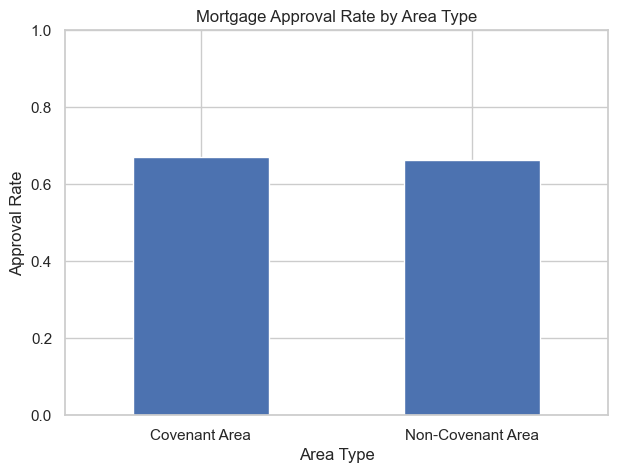

In [30]:
plt.figure(figsize=(7,5))
approval_rates.plot(kind="bar")
plt.title("Mortgage Approval Rate by Area Type")
plt.xlabel("Area Type")
plt.ylabel("Approval Rate")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.show()

This bar chart shows whether mortgage approvals are higher in one group than the other. If covenant areas have a noticeably lower approval rate, that suggests lending outcomes may still reflect historical inequality. Since approval is a major lending decision, this is one of the clearest indicators of possible algorithmic bias.

### Loan Term Comparison

#### 1.Interest rate comparison

In [31]:
# Average interest rate by area
interest_summary = df.groupby("covenant_area")["interest_rate"].mean()
print("Average interest rate by area:")
print(interest_summary)

Average interest rate by area:
covenant_area
Covenant Area        6.610344
Non-Covenant Area    6.570505
Name: interest_rate, dtype: float64


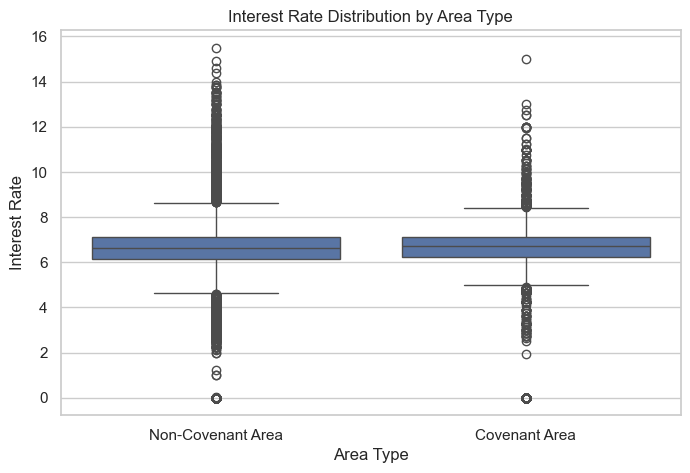

In [32]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="covenant_area", y="interest_rate")
plt.title("Interest Rate Distribution by Area Type")
plt.xlabel("Area Type")
plt.ylabel("Interest Rate")
plt.show()

This boxplot compares the spread of interest rates in covenant and non-covenant areas. If covenant areas show higher median interest rates or more high-rate outliers, that may indicate unequal loan conditions. This matters because algorithmic bias is not only about approval or denial, but also about the quality of terms people receive.

#### Loan amount comparison

In [33]:
# Average loan amount by area
loan_summary = df.groupby("covenant_area")["loan_amount"].mean()
print("Average loan amount by area:")
print(loan_summary)

Average loan amount by area:
covenant_area
Covenant Area        383043.692363
Non-Covenant Area    302042.401016
Name: loan_amount, dtype: float64


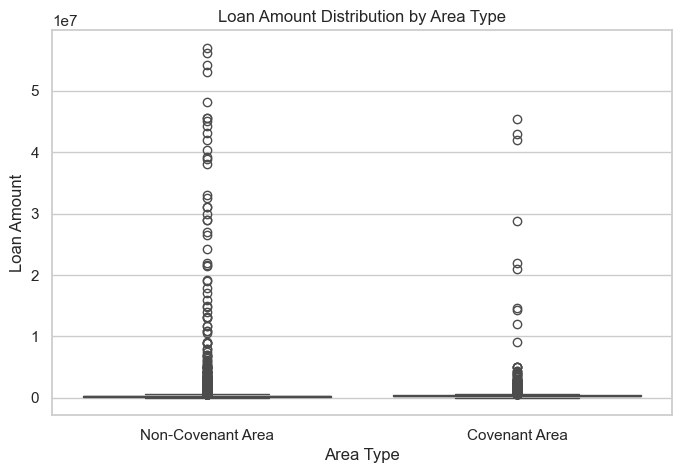

In [34]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="covenant_area", y="loan_amount")
plt.title("Loan Amount Distribution by Area Type")
plt.xlabel("Area Type")
plt.ylabel("Loan Amount")
plt.show()

This chart compares loan amounts across the two area types. If applicants in covenant areas receive lower loan amounts on average, it may show that lending systems are still shaped by neighborhood-level inequality. Lower loan amounts can affect home access, refinancing, and wealth-building opportunities.

### Proxy Variable Analysis

This part looks at variables that may indirectly carry the effect of race or historical segregation

#### Look at key proxy variables

In [35]:
# List of possible proxy variables
proxy_vars = [
    "property_value",
    "income",
    "tract_minority_population_percent",
    "tract_to_msa_income_percentage"
]

# Summary statistics by covenant area
proxy_summary = df.groupby("covenant_area")[proxy_vars].mean()
print(proxy_summary)

                   property_value      income  \
covenant_area                                   
Covenant Area       487349.429698  163.173426   
Non-Covenant Area   387560.383214  147.222444   

                   tract_minority_population_percent  \
covenant_area                                          
Covenant Area                              30.374508   
Non-Covenant Area                          21.940751   

                   tract_to_msa_income_percentage  
covenant_area                                      
Covenant Area                          110.928425  
Non-Covenant Area                      100.679432  


These variables may act as proxy variables because they are strongly connected to neighborhood history and economic inequality.

#### Visualize proxy variables

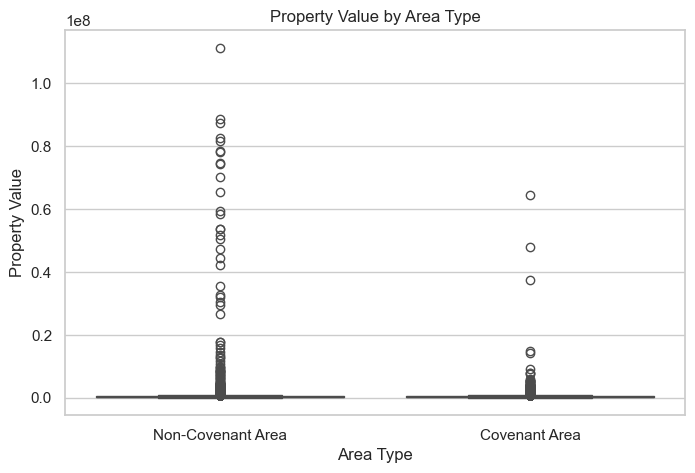

In [36]:
# Property value
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="covenant_area", y="property_value")
plt.title("Property Value by Area Type")
plt.xlabel("Area Type")
plt.ylabel("Property Value")
plt.show()

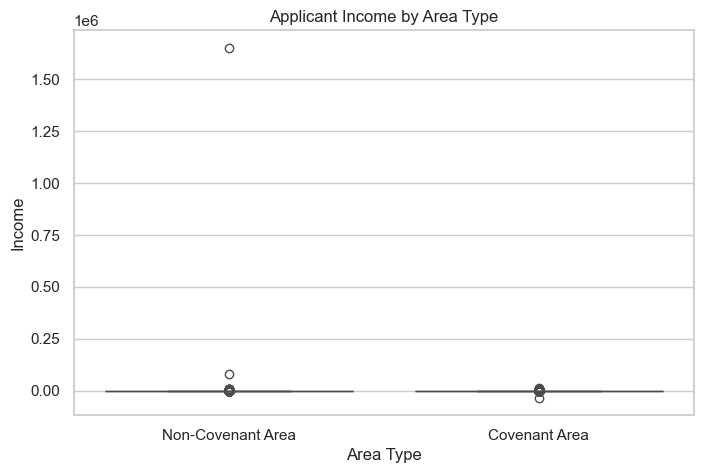

In [37]:
# Income
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="covenant_area", y="income")
plt.title("Applicant Income by Area Type")
plt.xlabel("Area Type")
plt.ylabel("Income")
plt.show()

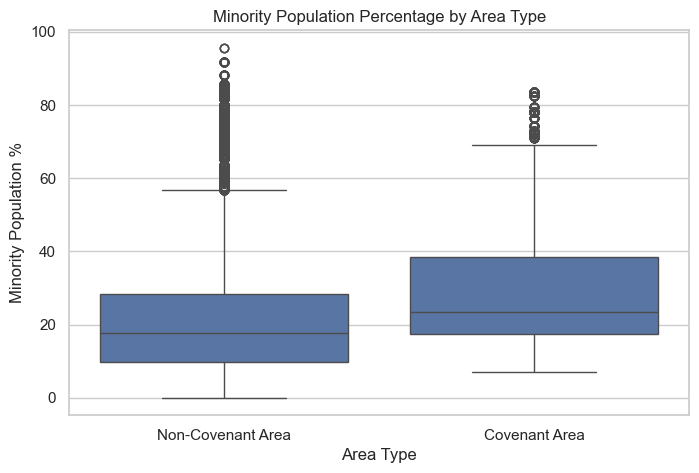

In [38]:
# Minority population percentage
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="covenant_area", y="tract_minority_population_percent")
plt.title("Minority Population Percentage by Area Type")
plt.xlabel("Area Type")
plt.ylabel("Minority Population %")
plt.show()

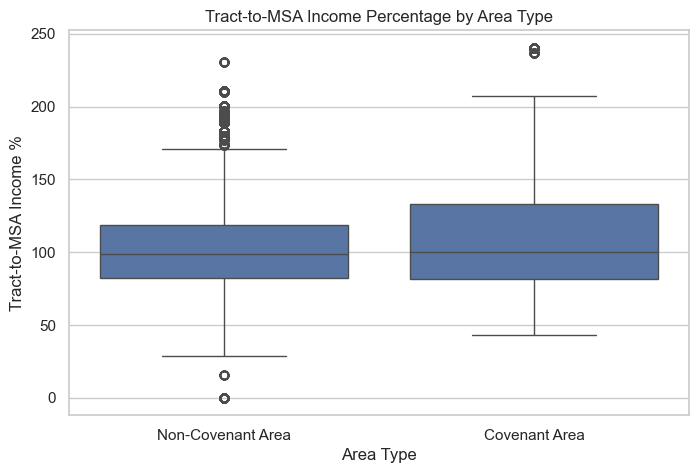

In [39]:
# Tract to MSA income percentage
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="covenant_area", y="tract_to_msa_income_percentage")
plt.title("Tract-to-MSA Income Percentage by Area Type")
plt.xlabel("Area Type")
plt.ylabel("Tract-to-MSA Income %")
plt.show()

These charts show whether covenant and non-covenant areas differ in property values, applicant income, neighborhood minority population, and local economic conditions. If strong differences appear here, it suggests that historical discrimination may still be embedded in the variables used by modern lending systems. Even without using race directly, models can still pick up these patterns through proxy variables.

### 4.Logistic Regression Results

This part checks whether covenant-related neighborhood history is associated with approval outcomes after controlling for other variables.

#### Prepare data for logistic regression

In [40]:
# Keep only the columns needed for the model
model_data = df[
    [
        "was_approved",
        "covenant_area_flag",
        "loan_amount",
        "property_value",
        "income",
        "tract_minority_population_percent",
        "tract_to_msa_income_percentage"
    ]
].copy()

# Drop rows with missing values in the model columns
model_data = model_data.dropna()

# Convert approval into 0/1
model_data["was_approved"] = model_data["was_approved"].astype(int)

print("Rows used in the model:", model_data.shape[0])
print(model_data.head())

Rows used in the model: 72751
     was_approved  covenant_area_flag  loan_amount  property_value  income  \
62              0                   0     475000.0        595000.0   168.0   
63              0                   0     645000.0        805000.0   207.0   
65              1                   0     525000.0        555000.0   277.0   
70              1                   0     665000.0        785000.0   182.0   
313             1                   0     365000.0        435000.0    91.0   

     tract_minority_population_percent  tract_to_msa_income_percentage  
62                                8.11                          128.09  
63                                8.87                          101.88  
65                               25.71                          144.96  
70                               41.44                           15.77  
313                              16.59                          126.61  


This prepares a clean dataset for regression by keeping only the needed variables and removing missing values.

#### Run logistic regression

In [41]:
# Define predictors (X) and target (y)
X = model_data[
    [
        "covenant_area_flag",
        "loan_amount",
        "property_value",
        "income",
        "tract_minority_population_percent",
        "tract_to_msa_income_percentage"
    ]
]

y = model_data["was_approved"]

# Add constant term
X = sm.add_constant(X)

# Fit logistic regression
logit_model = sm.Logit(y, X).fit()

# Print model results
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.420759
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:           was_approved   No. Observations:                72751
Model:                          Logit   Df Residuals:                    72744
Method:                           MLE   Df Model:                            6
Date:                Mon, 16 Mar 2026   Pseudo R-squ.:                 0.04690
Time:                        00:18:06   Log-Likelihood:                -30611.
converged:                       True   LL-Null:                       -32117.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const                                 0.0667      0.047      1

#### Summary

The logistic regression tests whether covenant-area history still has a relationship with mortgage approval after controlling for factors like income, loan amount, property value, and neighborhood characteristics. The most important variable in this model is covenant_area_flag. If its coefficient is negative, it suggests that being in a historically covenanted area is associated with lower approval odds. If it is statistically significant, that strengthens the argument that historical neighborhood inequality may still affect modern lending decisions.

Simple interpretation guide

Negative coefficient for covenant_area_flag → lower odds of approval in covenant areas

Positive coefficient → higher odds of approval

p-value < 0.05 → statistically significant relationship

#### Convert coefficients to odds ratios

In [42]:
# Turn coefficients into odds ratios for easier interpretation
odds_ratios = pd.DataFrame({
    "Variable": logit_model.params.index,
    "Coefficient": logit_model.params.values,
    "Odds_Ratio": np.exp(logit_model.params.values),
    "P_Value": logit_model.pvalues.values
})

print(odds_ratios)

                            Variable  Coefficient  Odds_Ratio        P_Value
0                              const     0.066669    1.068941   1.597177e-01
1                 covenant_area_flag    -0.015806    0.984319   6.532254e-01
2                        loan_amount    -0.000003    0.999997   1.331232e-67
3                     property_value     0.000003    1.000003   1.994012e-80
4                             income     0.003614    1.003621   5.253659e-60
5  tract_minority_population_percent     0.000958    1.000959   1.157829e-01
6     tract_to_msa_income_percentage     0.010002    1.010052  5.109525e-120


Odds ratios make the results easier to explain.
If the odds ratio for covenant_area_flag is less than 1, approval odds are lower in covenant areas.

This chart makes the fairness comparison easy to understand. If covenant areas have a lower approval rate, it suggests that historical geographic inequality may still be influencing modern lending decisions. This supports the idea that algorithmic systems can carry forward older patterns through neighborhood-based variables.

### 6.Correlation Analysis for Proxy Variables

This helps show which variables move together.

#### Create correlation heatmap

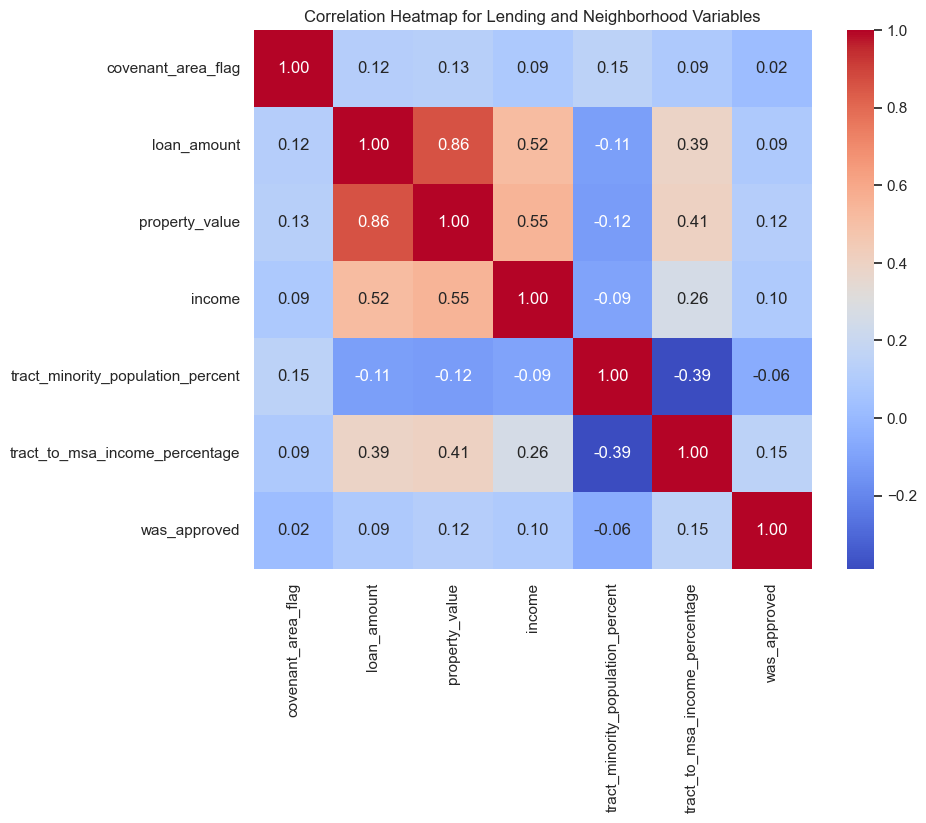

In [45]:
corr_data = model_data[
    [
        "covenant_area_flag",
        "loan_amount",
        "property_value",
        "income",
        "tract_minority_population_percent",
        "tract_to_msa_income_percentage",
        "was_approved"
    ]
]

corr_matrix = corr_data.corr()

plt.figure(figsize=(9,7))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap for Lending and Neighborhood Variables")
plt.show()

The heatmap helps identify which variables are closely related. If covenant area status is associated with property value, income measures, or minority population percentage, this supports the idea that these variables may act as proxies for historical segregation. If approval is also related to those variables, it suggests that algorithms may indirectly reproduce older patterns of discrimination.

### 7.Discussion of Bias

The analysis suggests that algorithmic bias in mortgage lending may not come from the direct use of race, but from the use of variables shaped by historical housing discrimination. Areas with a history of racial covenants may still differ in economic and neighborhood characteristics, and these differences can influence lending outcomes such as approvals, interest rates, and loan amounts. The results from group comparisons, fairness metrics, and logistic regression together help show whether modern systems may still reflect past inequities through proxy variables. This highlights an important ethical issue in data science: even when algorithms appear neutral, they can still reproduce patterns built into the data they learn from.

### 8.Conclusion

Overall, this section examined whether modern mortgage lending outcomes differ between historically covenanted and non-covenanted areas. The results from approval rate comparisons, loan term analysis, proxy variable exploration, and logistic regression provide evidence for evaluating whether modern lending systems may still reflect historical discrimination. Even if race is not directly included in the decision process, variables tied to neighborhood history and economic inequality can still influence algorithmic outcomes. This shows why fairness auditing and ethical review are important in lending-related data systems.